# Exploratory Data Analysis
# Japan Inflation Data EDA

This notebook performs an in-depth exploratory data analysis on Japan inflation data, including:
- Distribution analysis
- Statistical tests
- Time series characteristics analysis
- Correlation analysis
- Outlier detection

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import shapiro, normaltest, kstest, anderson, jarque_bera
import warnings
warnings.filterwarnings('ignore')

# Try importing statsmodels
STATSMODELS_AVAILABLE = False
try:
    from statsmodels.tsa.stattools import adfuller, kpss
    from statsmodels.stats.diagnostic import acorr_ljungbox
    from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
    STATSMODELS_AVAILABLE = True
    print("statsmodels imported successfully")
except ImportError as e:
    print(f"statsmodels import failed: {e}")
    print("Note: Stationarity tests and ACF/PACF plots will be skipped")
    print("Fix: pip install --upgrade statsmodels scipy")

# Set font and style
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial', 'Helvetica']
plt.rcParams['axes.unicode_minus'] = False
try:
    plt.style.use('seaborn-v0_8-darkgrid')
except:
    plt.style.use('seaborn-darkgrid')
sns.set_palette("husl")

# Display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.4f}'.format)

print(f"\nCurrent environment:")
print(f"  pandas: {pd.__version__}")
print(f"  numpy: {np.__version__}")
import scipy
print(f"  scipy: {scipy.__version__}")
print(f"  statsmodels available: {STATSMODELS_AVAILABLE}")

statsmodels imported successfully

Current environment:
  pandas: 3.0.2
  numpy: 2.4.4
  scipy: 1.17.1
  statsmodels available: True


## 1. Data Loading

In [2]:
# Load structured data
data = pd.read_csv('./data_clean/japan_inflation_structured_check.csv')

# Convert date and set index
data['Date'] = pd.to_datetime(data['YearMonth'], format='%Y-%m')
data = data.set_index('Date')
data = data.drop('YearMonth', axis=1)

# Data type conversion
data = data.replace('-', np.nan)
data = data.apply(pd.to_numeric, errors='coerce')

print(f"Data Shape: {data.shape}")
print(f"Date Range: {data.index.min()} to {data.index.max()}")
print(f"Total Observations: {len(data)} months")

Data Shape: (673, 57)
Date Range: 1970-01-01 00:00:00 to 2026-01-01 00:00:00
Total Observations: 673 months


## 2. Calculate Growth Rates

In [3]:
# Calculate 3-month annualized growth rate
def calculate_growth_rate(series, periods=3):
    """Calculate annualized growth rate"""
    return ((series / series.shift(periods)) - 1) * (12 / periods) * 100

# Calculate growth rates for all columns
data_growth = data.apply(lambda x: calculate_growth_rate(x, periods=3))

print(f"Growth rate data shape: {data_growth.shape}")
print(f"Growth rate missing values: {data_growth.isnull().sum().sum()}")

Growth rate data shape: (673, 57)
Growth rate missing values: 1023


## 3. Basic Descriptive Statistics

In [4]:
# Select key indicators for analysis
key_indicators = [
    'All items',
    'All items, less fresh food',
    'All items, less fresh food & energy',
    'Food',
    'Housing',
    'Fuel, light & water charges',
    'Transportation & communication',
    'Education'
]

# Filter existing columns
available_indicators = [col for col in key_indicators if col in data_growth.columns]

# Descriptive statistics
desc_stats = data_growth[available_indicators].describe()
print("\n=== Key Indicators Descriptive Statistics ===")
print(desc_stats)

# Additional statistics
print("\n=== Skewness & Kurtosis ===")
skew_kurt = pd.DataFrame({
    'Skewness': data_growth[available_indicators].skew(),
    'Kurtosis': data_growth[available_indicators].kurtosis()
})
print(skew_kurt)


=== Key Indicators Descriptive Statistics ===
       All items  All items, less fresh food
count   670.0000                    670.0000
mean      2.3900                      2.3636
std       5.0493                      4.7291
min      -7.3695                     -7.3171
25%      -0.8188                     -0.4683
50%       1.2513                      1.2520
75%       3.8741                      3.7450
max      44.4444                     36.8039

=== Skewness & Kurtosis ===
                            Skewness  Kurtosis
All items                     2.5427   12.4362
All items, less fresh food    2.4543    9.9548


## 4. Distribution Visualization

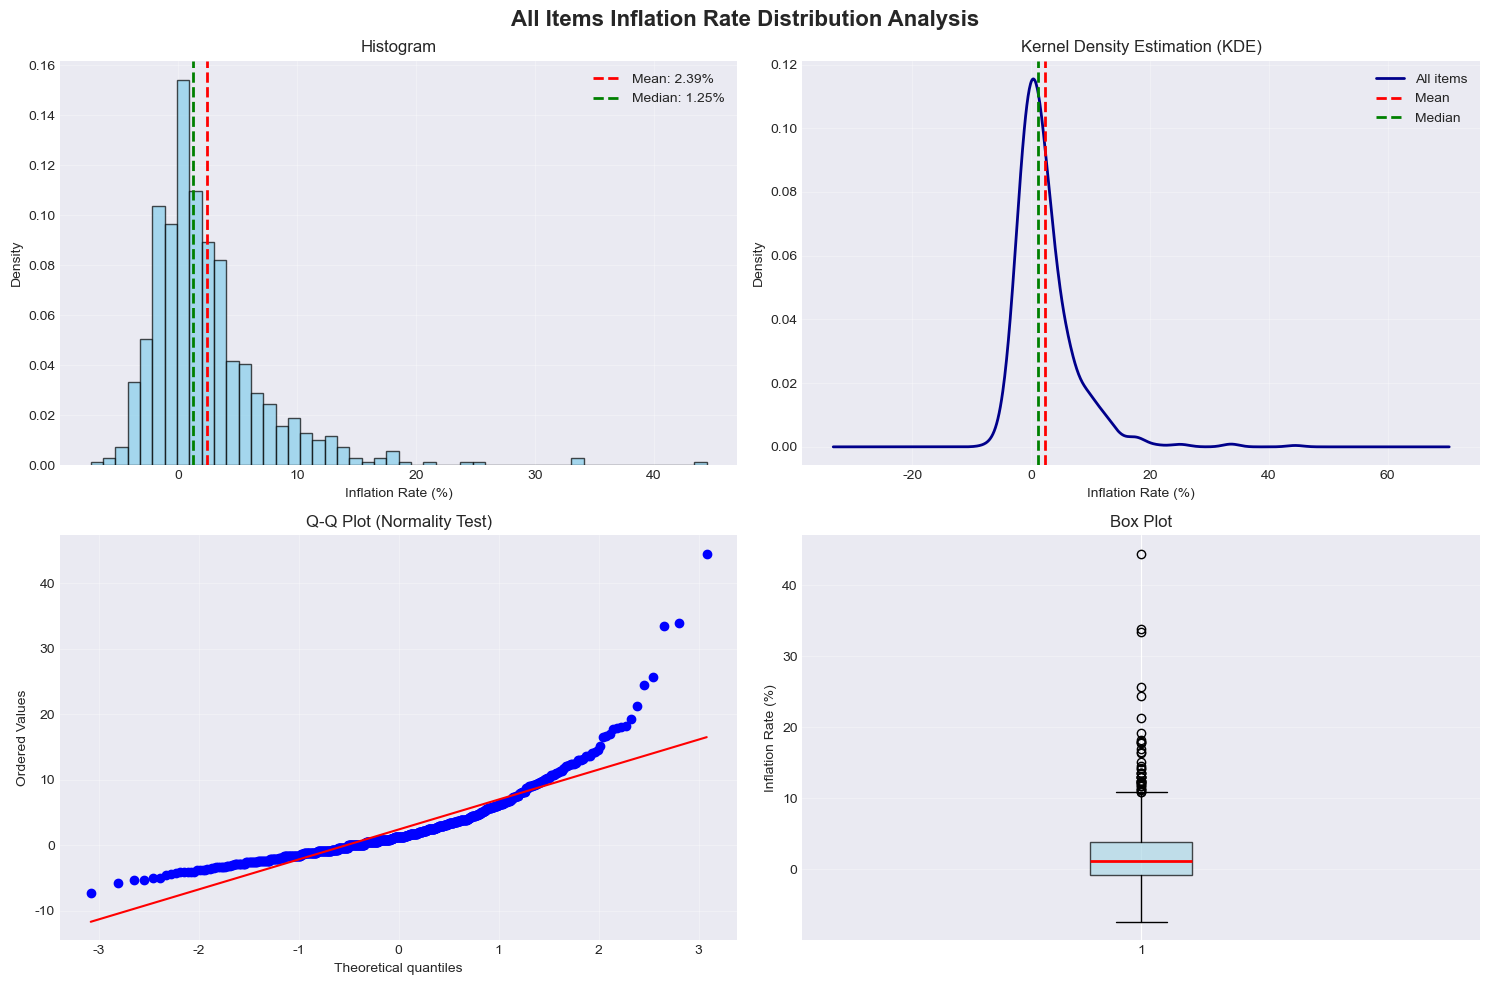

In [5]:
# 4.1 Overall inflation rate distribution analysis
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('All Items Inflation Rate Distribution Analysis', fontsize=16, fontweight='bold')

inflation = data_growth['All items'].dropna()

# Histogram + density plot
axes[0, 0].hist(inflation, bins=50, density=True, alpha=0.7, color='skyblue', edgecolor='black')
axes[0, 0].axvline(inflation.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {inflation.mean():.2f}%')
axes[0, 0].axvline(inflation.median(), color='green', linestyle='--', linewidth=2, label=f'Median: {inflation.median():.2f}%')
axes[0, 0].set_xlabel('Inflation Rate (%)')
axes[0, 0].set_ylabel('Density')
axes[0, 0].set_title('Histogram')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Kernel density estimation
inflation.plot(kind='kde', ax=axes[0, 1], color='darkblue', linewidth=2)
axes[0, 1].axvline(inflation.mean(), color='red', linestyle='--', linewidth=2, label='Mean')
axes[0, 1].axvline(inflation.median(), color='green', linestyle='--', linewidth=2, label='Median')
axes[0, 1].set_xlabel('Inflation Rate (%)')
axes[0, 1].set_ylabel('Density')
axes[0, 1].set_title('Kernel Density Estimation (KDE)')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Q-Q plot
stats.probplot(inflation, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title('Q-Q Plot (Normality Test)')
axes[1, 0].grid(True, alpha=0.3)

# Box plot
axes[1, 1].boxplot(inflation, vert=True, patch_artist=True,
                   boxprops=dict(facecolor='lightblue', alpha=0.7),
                   medianprops=dict(color='red', linewidth=2))
axes[1, 1].set_ylabel('Inflation Rate (%)')
axes[1, 1].set_title('Box Plot')
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

In [ ]:
# 4.2 Distribution comparison of key indicators
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Key Inflation Indicators Distribution Comparison', fontsize=16, fontweight='bold')

# Select 4 key indicators for comparison
compare_cols = available_indicators[:4] if len(available_indicators) >= 4 else available_indicators

for idx, col in enumerate(compare_cols):
    row = idx // 2
    col_idx = idx % 2
    
    series = data_growth[col].dropna()
    
    # Plot histogram and KDE
    axes[row, col_idx].hist(series, bins=40, density=True, alpha=0.6, color='steelblue', edgecolor='black')
    series.plot(kind='kde', ax=axes[row, col_idx], color='darkred', linewidth=2, secondary_y=False)
    axes[row, col_idx].axvline(series.mean(), color='red', linestyle='--', linewidth=1.5, alpha=0.7)
    axes[row, col_idx].set_title(col)
    axes[row, col_idx].set_xlabel('Growth Rate (%)')
    axes[row, col_idx].set_ylabel('Density')
    axes[row, col_idx].grid(True, alpha=0.3)
    
    # Add statistics
    textstr = f'Mean: {series.mean():.2f}%\nStd: {series.std():.2f}%\nSkewness: {series.skew():.2f}'
    axes[row, col_idx].text(0.02, 0.98, textstr, transform=axes[row, col_idx].transAxes,
                            fontsize=9, verticalalignment='top',
                            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

## 5. Normality Tests

In [ ]:
# Perform multiple normality tests on key indicators
def normality_tests(series, name):
    """Perform multiple normality tests"""
    series_clean = series.dropna()
    
    results = {}
    
    # 1. Shapiro-Wilk test (for sample size < 5000)
    if len(series_clean) < 5000:
        stat, p = shapiro(series_clean)
        results['Shapiro-Wilk'] = {'Statistic': stat, 'p-value': p, 'Conclusion': 'Non-Normal' if p < 0.05 else 'Normal'}
    
    # 2. Kolmogorov-Smirnov test
    stat, p = kstest(series_clean, 'norm', args=(series_clean.mean(), series_clean.std()))
    results['K-S'] = {'Statistic': stat, 'p-value': p, 'Conclusion': 'Non-Normal' if p < 0.05 else 'Normal'}
    
    # 3. Anderson-Darling test
    result = anderson(series_clean, dist='norm')
    results['Anderson-Darling'] = {
        'Statistic': result.statistic,
        'Critical Value (5%)': result.critical_values[2],
        'Conclusion': 'Non-Normal' if result.statistic > result.critical_values[2] else 'Normal'
    }
    
    # 4. Jarque-Bera test (based on skewness and kurtosis)
    stat, p = jarque_bera(series_clean)
    results['Jarque-Bera'] = {'Statistic': stat, 'p-value': p, 'Conclusion': 'Non-Normal' if p < 0.05 else 'Normal'}
    
    # 5. D'Agostino-Pearson test
    stat, p = normaltest(series_clean)
    results['D\'Agostino-Pearson'] = {'Statistic': stat, 'p-value': p, 'Conclusion': 'Non-Normal' if p < 0.05 else 'Normal'}
    
    return results

# Run normality tests on key indicators
print("\n" + "="*80)
print(" "*25 + "Normality Test Results")
print("="*80)

normality_results = {}
for col in available_indicators:
    print(f"\n{'='*80}")
    print(f"Indicator: {col}")
    print(f"{'='*80}")
    
    results = normality_tests(data_growth[col], col)
    normality_results[col] = results
    
    for test_name, result in results.items():
        print(f"\n{test_name} Test:")
        for key, value in result.items():
            if isinstance(value, float):
                print(f"  {key}: {value:.6f}")
            else:
                print(f"  {key}: {value}")

In [ ]:
# Normality test summary table
summary_data = []
for col, tests in normality_results.items():
    row = {'Indicator': col}
    for test_name, result in tests.items():
        if 'p-value' in result:
            row[test_name] = f"{result['p-value']:.4f} ({result['Conclusion']})"
        else:
            row[test_name] = result['Conclusion']
    summary_data.append(row)

summary_df = pd.DataFrame(summary_data)
print("\n" + "="*100)
print(" "*35 + "Normality Test Summary")
print("="*100)
print(summary_df.to_string(index=False))
print("\nNote: Format is 'p-value (Conclusion)', p < 0.05 rejects the normality hypothesis")

## 6. Time Series Stationarity Tests

In [ ]:
# 6.1 ADF Test (Augmented Dickey-Fuller Test)
def adf_test(series, name):
    """ADF stationarity test"""
    if not STATSMODELS_AVAILABLE:
        return None
    series_clean = series.dropna()
    result = adfuller(series_clean, autolag='AIC')
    
    return {
        'ADF Statistic': result[0],
        'p-value': result[1],
        'Critical Value 1%': result[4]['1%'],
        'Critical Value 5%': result[4]['5%'],
        'Critical Value 10%': result[4]['10%'],
        'Conclusion': 'Stationary' if result[1] < 0.05 else 'Non-Stationary'
    }

# 6.2 KPSS Test
def kpss_test(series, name):
    """KPSS stationarity test"""
    if not STATSMODELS_AVAILABLE:
        return None
    series_clean = series.dropna()
    result = kpss(series_clean, regression='c', nlags='auto')
    
    return {
        'KPSS Statistic': result[0],
        'p-value': result[1],
        'Critical Value 1%': result[3]['1%'],
        'Critical Value 5%': result[3]['5%'],
        'Critical Value 10%': result[3]['10%'],
        'Conclusion': 'Non-Stationary' if result[1] < 0.05 else 'Stationary'
    }

# Run stationarity tests
if not STATSMODELS_AVAILABLE:
    print("\nstatsmodels not available, skipping stationarity tests")
    print("Run: pip install --upgrade statsmodels scipy")
    stationarity_results = {}
else:
    print("\n" + "="*100)
    print(" "*35 + "Stationarity Test Results")
    print("="*100)

    stationarity_results = {}
    for col in available_indicators:
        print(f"\n{'='*100}")
        print(f"Indicator: {col}")
        print(f"{'='*100}")
        
        # ADF test
        adf_result = adf_test(data_growth[col], col)
        print("\nADF Test (H0: unit root exists, i.e., non-stationary):")
        for key, value in adf_result.items():
            if isinstance(value, float):
                print(f"  {key}: {value:.6f}")
            else:
                print(f"  {key}: {value}")
        
        # KPSS test
        kpss_result = kpss_test(data_growth[col], col)
        print("\nKPSS Test (H0: data is stationary):")
        for key, value in kpss_result.items():
            if isinstance(value, float):
                print(f"  {key}: {value:.6f}")
            else:
                print(f"  {key}: {value}")
        
        stationarity_results[col] = {'ADF': adf_result, 'KPSS': kpss_result}

In [ ]:
# Stationarity test summary table
if STATSMODELS_AVAILABLE and stationarity_results:
    stat_summary = []
    for col, tests in stationarity_results.items():
        stat_summary.append({
            'Indicator': col,
            'ADF Statistic': f"{tests['ADF']['ADF Statistic']:.4f}",
            'ADF p-value': f"{tests['ADF']['p-value']:.4f}",
            'ADF Conclusion': tests['ADF']['Conclusion'],
            'KPSS Statistic': f"{tests['KPSS']['KPSS Statistic']:.4f}",
            'KPSS p-value': f"{tests['KPSS']['p-value']:.4f}",
            'KPSS Conclusion': tests['KPSS']['Conclusion']
        })

    stat_df = pd.DataFrame(stat_summary)
    print("\n" + "="*120)
    print(" "*45 + "Stationarity Test Summary")
    print("="*120)
    print(stat_df.to_string(index=False))
    print("\nNote: ADF H0 = non-stationary; KPSS H0 = stationary")
else:
    print("\nSkipping stationarity test summary (statsmodels not available)")
    stat_df = pd.DataFrame()

## 7. Autocorrelation Tests

In [ ]:
# Plot ACF and PACF
if not STATSMODELS_AVAILABLE:
    print("\nstatsmodels not available, skipping ACF/PACF analysis")
    print("Run: pip install --upgrade statsmodels scipy")
else:
    fig, axes = plt.subplots(len(available_indicators[:4]), 2, figsize=(15, 4*len(available_indicators[:4])))
    fig.suptitle('Autocorrelation Function (ACF) and Partial Autocorrelation Function (PACF)', fontsize=16, fontweight='bold')

    for idx, col in enumerate(available_indicators[:4]):
        series = data_growth[col].dropna()
        
        # ACF plot
        plot_acf(series, lags=40, ax=axes[idx, 0], alpha=0.05)
        axes[idx, 0].set_title(f'{col} - ACF')
        axes[idx, 0].grid(True, alpha=0.3)
        
        # PACF plot
        plot_pacf(series, lags=40, ax=axes[idx, 1], alpha=0.05)
        axes[idx, 1].set_title(f'{col} - PACF')
        axes[idx, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

In [ ]:
# Ljung-Box test (test whether the series is white noise)
print("\n" + "="*100)
print(" "*35 + "Ljung-Box Autocorrelation Test")
print("="*100)
print("H0: The series is white noise (no autocorrelation)\n")

lb_results = []
for col in available_indicators:
    series = data_growth[col].dropna()
    lb_test = acorr_ljungbox(series, lags=[10, 20, 30], return_df=True)
    
    print(f"\nIndicator: {col}")
    print(lb_test)
    
    # Determine whether to reject H0
    conclusion = "Autocorrelation exists" if (lb_test['lb_pvalue'] < 0.05).any() else "No significant autocorrelation"
    lb_results.append({'Indicator': col, 'Conclusion': conclusion})

print("\n" + "="*100)
lb_df = pd.DataFrame(lb_results)
print(lb_df.to_string(index=False))

## 8. Correlation Analysis

In [ ]:
# 8.1 Compute correlation matrix
corr_matrix = data_growth[available_indicators].corr()

# Plot heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Inflation Indicators Correlation Heatmap', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("\nCorrelation Matrix:")
print(corr_matrix)

In [ ]:
# 8.2 Extract highly correlated pairs
def get_high_correlations(corr_matrix, threshold=0.7):
    """Extract highly correlated variable pairs"""
    high_corr = []
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            if abs(corr_matrix.iloc[i, j]) >= threshold:
                high_corr.append({
                    'Variable 1': corr_matrix.columns[i],
                    'Variable 2': corr_matrix.columns[j],
                    'Correlation': corr_matrix.iloc[i, j]
                })
    return pd.DataFrame(high_corr).sort_values('Correlation', key=abs, ascending=False)

high_corr_df = get_high_correlations(corr_matrix, threshold=0.7)
print("\n" + "="*80)
print(" "*20 + "Highly Correlated Pairs (|r| >= 0.7)")
print("="*80)
print(high_corr_df.to_string(index=False))

In [ ]:
# 8.3 Spearman rank correlation (suitable for non-normal data)
spearman_corr = data_growth[available_indicators].corr(method='spearman')

plt.figure(figsize=(12, 10))
sns.heatmap(spearman_corr, annot=True, fmt='.3f', cmap='viridis', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Spearman Rank Correlation Heatmap', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

## 9. Outlier Detection

In [ ]:
# 9.1 IQR-based outlier detection
def detect_outliers_iqr(series, multiplier=1.5):
    """Detect outliers using the IQR method"""
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - multiplier * IQR
    upper_bound = Q3 + multiplier * IQR
    
    outliers = series[(series < lower_bound) | (series > upper_bound)]
    return outliers, lower_bound, upper_bound

print("\n" + "="*100)
print(" "*30 + "Outlier Detection Results (IQR Method)")
print("="*100)

outlier_summary = []
for col in available_indicators:
    series = data_growth[col].dropna()
    outliers, lower, upper = detect_outliers_iqr(series)
    
    outlier_summary.append({
        'Indicator': col,
        'Outlier Count': len(outliers),
        'Outlier Ratio': f"{len(outliers)/len(series)*100:.2f}%",
        'Lower Bound': f"{lower:.2f}",
        'Upper Bound': f"{upper:.2f}"
    })
    
    if len(outliers) > 0:
        print(f"\n{col}:")
        print(f"  Outlier count: {len(outliers)} ({len(outliers)/len(series)*100:.2f}%)")
        print(f"  Normal range: [{lower:.2f}, {upper:.2f}]")
        print(f"  Outliers:\n{outliers.sort_values()}")

outlier_df = pd.DataFrame(outlier_summary)
print("\n" + "="*100)
print("Outlier Detection Summary:")
print(outlier_df.to_string(index=False))

In [ ]:
# 9.2 Z-score based outlier detection
def detect_outliers_zscore(series, threshold=3):
    """Detect outliers using Z-score method"""
    z_scores = np.abs(stats.zscore(series.dropna()))
    outliers = series[z_scores > threshold]
    return outliers

print("\n" + "="*100)
print(" "*30 + "Outlier Detection Results (Z-score Method, threshold=3)")
print("="*100)

zscore_summary = []
for col in available_indicators:
    series = data_growth[col].dropna()
    outliers = detect_outliers_zscore(series, threshold=3)
    
    zscore_summary.append({
        'Indicator': col,
        'Outlier Count': len(outliers),
        'Outlier Ratio': f"{len(outliers)/len(series)*100:.2f}%"
    })

zscore_df = pd.DataFrame(zscore_summary)
print(zscore_df.to_string(index=False))

In [ ]:
# 9.3 Outlier visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Outlier Detection Visualization (First 4 Indicators)', fontsize=16, fontweight='bold')

for idx, col in enumerate(available_indicators[:4]):
    row = idx // 2
    col_idx = idx % 2
    
    series = data_growth[col].dropna()
    outliers, lower, upper = detect_outliers_iqr(series)
    
    # Time series plot with outliers marked
    axes[row, col_idx].plot(series.index, series.values, 'b-', alpha=0.6, linewidth=1, label='Normal')
    axes[row, col_idx].axhline(y=lower, color='r', linestyle='--', alpha=0.7, label=f'Lower: {lower:.2f}')
    axes[row, col_idx].axhline(y=upper, color='r', linestyle='--', alpha=0.7, label=f'Upper: {upper:.2f}')
    
    if len(outliers) > 0:
        axes[row, col_idx].scatter(outliers.index, outliers.values, color='red', s=50, 
                                   zorder=5, label=f'Outliers ({len(outliers)})')
    
    axes[row, col_idx].set_title(col)
    axes[row, col_idx].set_xlabel('Time')
    axes[row, col_idx].set_ylabel('Growth Rate (%)')
    axes[row, col_idx].legend(loc='best')
    axes[row, col_idx].grid(True, alpha=0.3)
    axes[row, col_idx].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 10. Time Series Feature Analysis

In [ ]:
# 10.1 Rolling statistics analysis
fig, axes = plt.subplots(2, 1, figsize=(16, 10))
fig.suptitle('All Items - Rolling Mean and Rolling Standard Deviation', fontsize=16, fontweight='bold')

inflation = data_growth['All items'].dropna()
window = 12  # 12-month rolling window

rolling_mean = inflation.rolling(window=window).mean()
rolling_std = inflation.rolling(window=window).std()

# Rolling mean
axes[0].plot(inflation.index, inflation.values, 'lightblue', alpha=0.5, label='Raw Data')
axes[0].plot(rolling_mean.index, rolling_mean.values, 'darkblue', linewidth=2, label=f'{window}-Month Rolling Mean')
axes[0].set_ylabel('Inflation Rate (%)')
axes[0].set_title('Rolling Mean')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Rolling standard deviation
axes[1].plot(rolling_std.index, rolling_std.values, 'darkred', linewidth=2, label=f'{window}-Month Rolling Std')
axes[1].fill_between(rolling_std.index, 0, rolling_std.values, alpha=0.3, color='red')
axes[1].set_xlabel('Time')
axes[1].set_ylabel('Standard Deviation (%)')
axes[1].set_title('Rolling Standard Deviation (Volatility)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# 10.2 Monthly seasonality analysis
# Extract month information
inflation_with_month = data_growth['All items'].dropna().to_frame()
inflation_with_month['Month'] = inflation_with_month.index.month

# Group by month
monthly_stats = inflation_with_month.groupby('Month')['All items'].agg(['mean', 'std', 'count'])
monthly_stats.index = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                       'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

print("\n" + "="*80)
print(" "*25 + "Monthly Seasonality Statistics")
print("="*80)
print(monthly_stats)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Monthly Seasonality Analysis', fontsize=14, fontweight='bold')

# Monthly average
axes[0].bar(range(12), monthly_stats['mean'].values, color='steelblue', alpha=0.7, edgecolor='black')
axes[0].set_xticks(range(12))
axes[0].set_xticklabels(monthly_stats.index, rotation=45)
axes[0].set_ylabel('Average Inflation Rate (%)')
axes[0].set_title('Average Inflation Rate by Month')
axes[0].grid(True, alpha=0.3, axis='y')

# Monthly standard deviation
axes[1].bar(range(12), monthly_stats['std'].values, color='coral', alpha=0.7, edgecolor='black')
axes[1].set_xticks(range(12))
axes[1].set_xticklabels(monthly_stats.index, rotation=45)
axes[1].set_ylabel('Standard Deviation (%)')
axes[1].set_title('Inflation Rate Volatility by Month')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 11. Comprehensive Statistical Test Summary

In [ ]:
# Create comprehensive statistical test summary table
comprehensive_summary = []

for col in available_indicators:
    series = data_growth[col].dropna()
    
    # Basic statistics
    mean_val = series.mean()
    std_val = series.std()
    skew_val = series.skew()
    kurt_val = series.kurtosis()
    
    # Normality test (Shapiro-Wilk)
    if len(series) < 5000:
        _, shapiro_p = shapiro(series)
        normality = "Yes" if shapiro_p >= 0.05 else "No"
    else:
        shapiro_p = np.nan
        normality = "N/A"
    
    # Stationarity test (ADF)
    adf_result = adfuller(series, autolag='AIC')
    stationarity = "Yes" if adf_result[1] < 0.05 else "No"
    
    # Outlier detection
    outliers, _, _ = detect_outliers_iqr(series)
    outlier_pct = len(outliers) / len(series) * 100
    
    comprehensive_summary.append({
        'Indicator': col,
        'Mean': f"{mean_val:.2f}%",
        'Std': f"{std_val:.2f}%",
        'Skewness': f"{skew_val:.2f}",
        'Kurtosis': f"{kurt_val:.2f}",
        'Normal': normality,
        'Stationary': stationarity,
        'Outlier Ratio': f"{outlier_pct:.2f}%"
    })

comprehensive_df = pd.DataFrame(comprehensive_summary)

print("\n" + "="*120)
print(" "*40 + "Comprehensive Statistical Test Summary")
print("="*120)
print(comprehensive_df.to_string(index=False))
print("\nNotes:")
print("  - Normal: Based on Shapiro-Wilk test (p >= 0.05 = normal)")
print("  - Stationary: Based on ADF test (p < 0.05 = stationary)")
print("  - Outliers: Based on IQR method")

## 12. Save EDA Results

In [ ]:
# Save summary tables to CSV files
comprehensive_df.to_csv('../data_clean/eda_comprehensive_summary.csv', index=False, encoding='utf-8-sig')
print("Comprehensive summary saved to: data_clean/eda_comprehensive_summary.csv")

stat_df.to_csv('../data_clean/eda_stationarity_tests.csv', index=False, encoding='utf-8-sig')
print("Stationarity test results saved to: data_clean/eda_stationarity_tests.csv")

outlier_df.to_csv('../data_clean/eda_outlier_detection.csv', index=False, encoding='utf-8-sig')
print("Outlier detection results saved to: data_clean/eda_outlier_detection.csv")

corr_matrix.to_csv('../data_clean/eda_correlation_matrix.csv', encoding='utf-8-sig')
print("Correlation matrix saved to: data_clean/eda_correlation_matrix.csv")

print("\nAll EDA results saved successfully!")

## EDA Summary

This notebook completed the following exploratory data analyses:

### 1. Distribution Analysis
- Histogram, kernel density estimation, Q-Q plot, box plot
- Descriptive statistics (mean, standard deviation, skewness, kurtosis)

### 2. Normality Tests
- Shapiro-Wilk test
- Kolmogorov-Smirnov test
- Anderson-Darling test
- Jarque-Bera test
- D'Agostino-Pearson test

### 3. Time Series Stationarity Tests
- ADF stationarity test
- KPSS stationarity test
- Ljung-Box autocorrelation test
- ACF/PACF analysis

### 4. Correlation Analysis
- Pearson correlation coefficient
- Spearman rank correlation
- Correlation heatmap

### 5. Outlier Detection
- IQR method
- Z-score method
- Outlier visualization

### 6. Time Series Features
- Rolling statistics (mean, standard deviation)
- Seasonality analysis

All analysis results have been saved to CSV files for subsequent reporting and analysis.